# Training RT-DETR Cell Instance Detection

## Preparations
### Import required libraries

In [2]:
import os
import sys
import time
import pickle
import json
from typing import Tuple, Union, List, Dict, Final, Optional

import numpy as np
from PIL import Image
import cv2
import torch
import torch.nn as nn
import pycocotools
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask_util
import albumentations as A
from transformers import AutoImageProcessor
# sys.path.append('references/detection')
# from references.detection.coco_utils  import CocoDetection
from torchvision.datasets import CocoDetection

## Pre-processing configurations
The following configurations are used for pre-processing the images during the training. 

In [3]:
# probability of adding random blur and salt-and-pepper or additive gaussian noise to the training images
# see the image Transforms section below
P_NOISE = 0.25

# the lower and upper bounds for random scaling the images (and annotated masks) for training augmentation
MIN_RANDOM_SCALE = 0.7
MAX_RANDOM_SCALE = 1.0

# model input image size (should be square and divisable by 14 because of DINOv2 backbone)
MODEL_INPUT_SIZE: Final[int] = 672 # will not be used without Dinov2 backbone

MIN_AREA: Final[int] = 16

### Transforms
We are using `Albumentations` package for all image and annotation augmentations.  

In [4]:
def get_transform(train: bool = True) -> A.core.composition.Compose:
    # no resizing is needed here as the training images are already cropped with the model input size, 
    # and also the Hugging face processor will handle any needed resizing
    if train:
        # random noise addition and random scale as defined above, 
        # we call these before PILToTensor as these classes 
        # operates on PIL images
        trsfms = [
            A.RandomScale(scale_limit=(MIN_RANDOM_SCALE - 1.0, MAX_RANDOM_SCALE - 1.0), p=1.0),
            A.PadIfNeeded(min_height = MODEL_INPUT_SIZE, min_width = MODEL_INPUT_SIZE, position = 'random'),
            A.RandomCrop(height = MODEL_INPUT_SIZE, width=MODEL_INPUT_SIZE, pad_if_needed=False, p=1.0),
            A.RandomRotate90(),
            A.Perspective(p=P_NOISE),
            A.RandomBrightnessContrast(p=P_NOISE),
            A.HueSaturationValue(p=P_NOISE),
            A.AdditiveNoise(p=P_NOISE, spatial_mode='per_pixel')
        ]        
    else:
        # test set 
        trsfms = [A.NoOp()]

    # bbox format is defined as COCO xywh
    return A.Compose(trsfms, bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True, min_area=MIN_AREA))

# hugging face 
# we need to resize the input images (not needed as they are already in the correct MODEL_INPUT_SIZE x MODEL_INPUT_SIZE input size, 
# and normalize them, we use the already implemented Hugging Face preprocessor for this conversion
# index 0 will be used 


from transformers import RTDetrImageProcessor
hg_preprocessor: RTDetrImageProcessor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_v2_r18vd")
# make the RT-DETR processor to be consistent with the DinoV2 backbone in terms of normalization and resizing
hg_preprocessor.do_normalize = True
hg_preprocessor.resample = 3
hg_preprocessor.size = {
    "height": MODEL_INPUT_SIZE,
    "width": MODEL_INPUT_SIZE
}

## Data Model
The dataset class as well as the training and evaluation scripts are adopted from the RT-DETR fine-tuning tuturial Notebook here:  https://github.com/NielsRogge/Transformers-Tutorials/blob/master/RT-DETR/Fine_tune_RT_DETR_on_a_custom_dataset.ipynb. 

NOTE: The labels (class IDs) for both YOLO and RT-DETR models starts with 0.

### Dataset for already pre-processed annotated data
This dataset is built by passing the location of the pre-processed images and corresponding json annotation file in COCO format. The code below assumes:
1. The train/test data is already cropped and the annotation files are already created in the required Mask R-CNN or YOLO format.
2. `convert_to_coco_api` function has been run on them to generate the json annotation file in COCO formet.

The dataset class takes care of image augmentation and any preprocessing that is required for the model. 

### Dataset folder and label map
NOTE: 
1. Make sure the the model label map class IDs (specified by LABEL_MAP below) are consistent with the parsed and cropped class IDs. 
2. For DETR models including RT-DETR variants, the model label map class IDs start from 0. When calling `convert_to_coco_api`, make sure to specify whether the cropped data is coming from Mask R-CNN (class IDs starting from 1) or from YOLO by setting the `CROPPED_FOR_MASK_RCNN` flag correctly. 

In [5]:
DATASET_BASE_PATH: str = '/home/cellareye/Cellanome/dl-mehdi/Mask RCNN/data/down_sampled_all_4_class_for_DINOv2'
CROPPED_TRAIN_IMAGES_PATH: str = os.path.join(DATASET_BASE_PATH, 'images', 'train')
CROPPED_TEST_IMAGES_PATH: str = os.path.join(DATASET_BASE_PATH, 'images', 'test')

# mapping between the class IDs and class names for the annotated data 
# labels start from 0
LABEL_MAP = {0: 'cell', 1: 'bead', 2: 'soma', 3: 'cell-adhered'}
REVERESE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

In [6]:
class CellMaskDataset(torch.utils.data.Dataset):
    def __init__(self, 
                 dataset_coco: CocoDetection, 
                 processor: AutoImageProcessor, 
                 instance_segmentation: bool = False,
                 transforms: A.core.composition.Compose = None):
        self.dataset_coco = dataset_coco
        self.processor = processor
        self.instance_segmentation = instance_segmentation
        self.transforms = transforms

   
    def __len__(self):
        return len(self.dataset_coco)

    def __getitem__(self, idx):
        image, annotations = self.dataset_coco[idx]
        
        # Convert image to RGB numpy array
        image_array: np.ndarray = np.array(image.convert("RGB"))
        
        if isinstance(annotations, dict):
            # references.detection.coco_utils.CocoDetection class, annotations is a dictionary with keys image_id, annotations
            # annotations['annotations'] is a list of annotation dictionaries
            image_id: int = annotations['image_id']
            boxes: np.ndarray = np.array([record['bbox'] for record in annotations['annotations']])
            labels: List[int] = [record['category_id'] for record in annotations['annotations']]
            if self.instance_segmentation:
                masks: List[np.ndarray] = [coco_mask_util.decode(record['segmentation']) for record in annotations['annotations']]
        else:
            # torchvision.datasets.CocoDetection class, annotations is a list of dictionaries for each annotated object
            if len(annotations) > 0:
                image_id: int = annotations[0]['image_id']
            else:
                image_id: int = idx + 1
            boxes: np.ndarray = np.array([record['bbox'] for record in annotations])
            labels: List[int] = [record['category_id'] for record in annotations]
            if self.instance_segmentation:
                masks: List[np.ndarray] = [coco_mask_util.decode(record['segmentation']) for record in annotations]
        
        # apply augmentations, the second condition should not happen (all preprocessed images should at least have one object)
        if self.transforms and len(boxes) > 0:
            if self.instance_segmentation:
                # TODO: check to make sure the below mask transform would work
                transformed = self.transforms(image=image_array, bboxes=boxes, masks=masks, category=labels)
                img = transformed["image"]
                boxes = transformed["bboxes"]
                masks = transformed["masks"]
                labels = transformed["category"]
            else:
                transformed = self.transforms(image=image_array, bboxes=boxes, category=labels)
                img = transformed["image"]
                boxes = transformed["bboxes"]
                labels = transformed["category"]

        # reformat annotations
        annotations: List[dict] = []
        for i, bbox in enumerate(boxes):
            record = {
                "image_id": image_id,
                "category_id": int(labels[i]),
                "bbox": np.array([int(v) for v in bbox]),
                "iscrowd": 0,
                "area": bbox[2] * bbox[3],
            }
            if self.instance_segmentation:
                record["segmentation"] = coco_mask_util.encode(np.asarray(masks[i], order="F"))
                record["segmentation"]['counts'] = record["segmentation"]['counts'].decode('utf8')
            annotations.append(record)

        formatted_annotation: dict = {"image_id": image_id, "annotations": annotations,}
        if self.processor is not None:
            results = self.processor(images=img, annotations=formatted_annotation, return_tensors="pt")

            # image processor expands batch dimension, lets squeeze it
            results = {k: v.squeeze() if isinstance(v, torch.Tensor) else v[0] for k, v in results.items()}
            return results
         
        return img, formatted_annotation

#### A function to convert our already cropped dataset to COCO dataset format
Use this function to convert the already cropped train/test datasets to COCO format and save the json annotation files. It only needs to be called onces. Onces the train and test json annotation files are created, there is no need to call this function again. 

In [ ]:
from tqdm import tqdm
# A flag to indicate whether the cropped images/annotations are for Mask RCNN or YOLO
CROPPED_FOR_MASK_RCNN: bool = True
if CROPPED_FOR_MASK_RCNN:
    annots_folder_name: str = "masks"
else:
    annots_folder_name: str = "labels"

CROPPED_TRAIN_ANNOTATIONS_PATH = os.path.join(DATASET_BASE_PATH, annots_folder_name, 'train')
CROPPED_TEST_ANNOTATIONS_PATH = os.path.join(DATASET_BASE_PATH, annots_folder_name, 'test')


def expand_bbox(
    bbox: Union[List[int], Tuple[int], np.ndarray], 
    image_width: int, 
    image_height: int, 
    percentage_to_expand_bbox_boundaries: float
) -> List[int]:
    
    xtl, ytl, xbr, ybr = bbox
    delta_x: int = int(percentage_to_expand_bbox_boundaries * (xbr - xtl) / 2)
    delta_y: int = int(percentage_to_expand_bbox_boundaries * (ybr - ytl) / 2)
    # expand by one pixel on each side at least to cover boundaries            
    delta_x = max(1, delta_x)
    delta_y = max(1, delta_y)
            
    xmin: int = max(0, xtl - delta_x)
    ymin: int = max(0, ytl - delta_y)
    xmax: int = min(image_width, xbr + delta_x)
    ymax: int = min(image_height, ybr + delta_y)
    
    return [xmin, ymin, xmax, ymax]

def convert_to_coco_api(images_path: str, 
                        annotations_path: str, 
                        id2label: Dict[int, str], # this is for the converted dataset, should start with 0 for YOLO, DETR models (RT/RF), 
                                                  # and 1 for Mask R-CNN/Mask2Fomer
                        instance_segmentation: bool = False,
                        percentage_to_expand_bbox_boundaries: float = 0.0):
    # load all images and annotations
    # the assumption is the image and its annotation use the same name
    imgs = list(sorted(os.listdir(images_path)))
    annotations = list(sorted(os.listdir(annotations_path)))
    start_class_id: int = min(list(id2label.keys()))
    
    if len(imgs) != len(annotations):
        print("[ERROR]: The list of images and masks are not consistent")
        return False, {}
    
    for i, img_filename in enumerate(imgs):
        # drop the image/mask filename extension 
        # (anything after the last '.' in the filename is considered as extension)
        img_name = ".".join(img_filename.strip().split('.')[:-1])
        annots_name = ".".join(annotations[i].strip().split('.')[:-1])
        if img_name != annots_name:
            print("[ERROR]: Inconsistent annotations file :{} found for image file: {}".format(annots_name, img_name))
            return False, {}
    # the index for annotations starts at 1
    annots_id = 1
    categories = set()
    json_annotations = {"images": [], "categories": [], "annotations": []}
    for idx in tqdm(range(len(imgs))):
        # load the image
        img_path = os.path.join(images_path, imgs[idx])
        # read the image, we only read the image to get the size of it
        # so no need to change the format (BGR to RGB) or convert to PIL 
        opencv_img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        image_height, image_width = opencv_img.shape[:2]
        img_dict = {}
        img_dict["id"] = idx + 1
        img_dict["file_name"] = imgs[idx]
        img_dict["height"] = image_height
        img_dict["width"] = image_width
        json_annotations["images"].append(img_dict)


        # annotations
        boxes: List[List[int]] = []
        labels: List[int] = []
        masks: List[np.ndarray] = []
        # load the annotations (masks)
        annots_path = os.path.join(annotations_path, annotations[idx])

        if instance_segmentation:
            # load the annotations
            filehandler = open(annots_path, 'rb')
            annots = pickle.load(filehandler)
            filehandler.close()
            
            for record in annots['annotations']:
                xtl, ytl, xbr, ybr = record['bbox']
                # no need to check the validity 
                if xtl >= xbr or ytl >= ybr:
                    continue
                # subtract 1 - start_class_id to adjust the labels
                # class IDs start from 1 in Mask R-CNN annotations, so if training YOLO/DETR, subtract 1
                # otherwise, leave the labels as is
                labels.append(int(record['category_id'] - 1 + start_class_id))
                mask: np.ndarray = coco_mask_util.decode(record['segmentation'])
                # mask in full image resolution
                full_res_mask: np.ndarray = np.zeros((image_height, image_width), np.uint8)
                full_res_mask[ytl:ybr, xtl:xbr] = mask
                
                masks.append(full_res_mask)
                
                expanded_bbox = expand_bbox(
                    bbox=[xtl, ytl, xbr, ybr],
                    image_width=image_width, 
                    image_height=image_height, 
                    percentage_to_expand_bbox_boundaries=percentage_to_expand_bbox_boundaries
                )
                # will convert bbox to xtl, ytl, w, h format below
                boxes.append(expanded_bbox)
        else:
            with open(annots_path,'r') as annot_file:
                for line in annot_file:
                    fields = line.strip().split(' ')
                    (label, center_x, center_y, w, h) = fields
                    xtl = int((float(center_x) - float(w) / 2.0) * image_width)
                    ytl = int((float(center_y) - float(h) / 2.0) * image_height)
                    xbr = int((float(center_x) + float(w) / 2.0) * image_width)
                    ybr = int((float(center_y) + float(h) / 2.0) * image_height)
                    if xtl >= xbr or ytl >= ybr:
                        continue
                    # convert the label to an integer from string
                    # for YOLO, labels start from 0, adjust the starting class IDs if needed
                    label = int(label + start_class_id) 
                    expanded_bbox: List[int] = expand_bbox(
                        bbox=[xtl, ytl, xbr, ybr],
                        image_width=image_width, 
                        image_height=image_height, 
                        percentage_to_expand_bbox_boundaries=percentage_to_expand_bbox_boundaries
                    )
                    # will convert bbox to xtl, ytl, w, h format below
                    boxes.append(expanded_bbox)
                    labels.append(label)
        
        for i, box in enumerate(boxes):
            record = {}
            record["image_id"] = idx + 1
            record['category_id'] = labels[i] 
            categories.add(record['category_id'])
            if instance_segmentation:
                record["segmentation"] = coco_mask_util.encode(np.asarray(masks[i], order="F"))
                record["segmentation"]['counts'] = record["segmentation"]['counts'].decode('utf8')
            xmin, ymin, xmax, ymax = [int(v) for v in box]
            #convert to xywh
            record['bbox'] = [xmin, ymin, xmax - xmin, ymax - ymin]
            record["area"] = (ymax - ymin) * (xmax - xmin)
            record["iscrowd"] = 0
            record["id"] = annots_id
                
            json_annotations["annotations"].append(record)
            annots_id += 1 
            
    json_annotations["categories"] = [{"id": i, "name": id2label[i], "supercategory": "biology"} for i in sorted(categories)]
    return True, json_annotations

import json

success, json_annots = convert_to_coco_api(images_path=CROPPED_TRAIN_IMAGES_PATH, 
                                           annotations_path=CROPPED_TRAIN_ANNOTATIONS_PATH, 
                                           id2label=LABEL_MAP,
                                           instance_segmentation = CROPPED_FOR_MASK_RCNN)
with open(os.path.join(DATASET_BASE_PATH, 'train_annotations.json'), 'w') as file:
    json.dump(json_annots, file)

success, json_annots = convert_to_coco_api(images_path=CROPPED_TEST_IMAGES_PATH, 
                                           annotations_path=CROPPED_TEST_ANNOTATIONS_PATH, 
                                           id2label=LABEL_MAP,
                                           instance_segmentation = CROPPED_FOR_MASK_RCNN)
with open(os.path.join(DATASET_BASE_PATH, 'test_annotations.json'), 'w') as file:
    json.dump(json_annots, file)

### Dataset prepration
----------------
The code assumes the train and test json annotation files are named `train_annotations.json` and `test_annotations.json`, respectively, and are placed under the root dataset folder, and the train and test images are stored under `images/train` and `images/test` folders under the root dataset folder.

Make sure the LABEL_MAP below is consistent with the way the annotations are parsed (the mapping between the annotation class names in the raw annotation format and the mapped class IDs), and the mapping between the model class IDs and names. 

In [7]:
# read the prepared json annotations in COCO format as COCO dataset objects
train_dataset_coco = CocoDetection(
    root=CROPPED_TRAIN_IMAGES_PATH, 
    annFile=os.path.join(DATASET_BASE_PATH, 'train_annotations.json'), 
    transforms=None
)
test_dataset_coco = CocoDetection(
    root=CROPPED_TEST_IMAGES_PATH, 
    annFile=os.path.join(DATASET_BASE_PATH, 'test_annotations.json'), 
    transforms=None
)

train_dataset = CellMaskDataset(
    dataset_coco=train_dataset_coco, 
    processor=hg_preprocessor,
    instance_segmentation=False, # no need to set to True for training a DETR model as it adds to runtime computation! set True for testing
    transforms=get_transform(True)
)

test_dataset = CellMaskDataset(
    dataset_coco=test_dataset_coco, 
    processor=hg_preprocessor,
    instance_segmentation=False, # no need to set to True for training a DETR model as it adds to runtime computation
    transforms=get_transform(False)
)

loading annotations into memory...
Done (t=8.19s)
creating index...
index created!
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!


## Model Definition

In [8]:
# the path for loading and saving model checkpoints
MODEL_PATH: str = 'checkpoints/rt_detr_checkpoints_3'
DINOV2_BACKBONE_INITIAL_CHECKPOINT: str = 'dinov2_backbone_with_fpn'
CUSTOM_RT_DETR_WITH_DINOV2_BACKBONE_INITIAL_CHECKPOINT: str = 'custom_rt_detr_with_dinov2_backbone'

### Backbone

In [9]:
from dinov2_backbone_with_fpn import Dinov2BackBoneWithFPNConfig, Dinov2BackBoneWithFPN

### RT-DETR Model Definition

In [10]:
from transformers import RTDetrImageProcessor, RTDetrV2ForObjectDetection
from custom_rt_detr_with_dinov2_backbone import RTDetrV2ConfigWithCustomBackBone, RTDetrV2ForObjectDetectionWithCustomBackbone

## Prepare the initial checkpoint for the custom model
The section can be skipped once the initial checkpoints are created.
### Backbone
We use our custome DINOv2 bacbone with FPN with the base model by default for now. This can be updated later. The DINOv2 weights are frozen, and the FPN weights are randomly initialized. The warning below can safely be ignored.  

In [12]:
if not os.path.exists(os.path.join(MODEL_PATH, DINOV2_BACKBONE_INITIAL_CHECKPOINT)):
    dinov2_backbone = Dinov2BackBoneWithFPN.from_pretrained(
        "facebook/dinov2-base", 
        # first_layer_dims = (48, 48), 
        output_indices_for_fpn = [4, 8, 12]
    )
    dinov2_backbone.save_pretrained(os.path.join(MODEL_PATH, DINOV2_BACKBONE_INITIAL_CHECKPOINT))
else:
    print("Dinov2 with FPN backbone initial checkpoint already created!")

You are using a model of type dinov2 to instantiate a model of type dinov2_backbone_with_fpn. This is not supported for all configurations of models and can yield errors.


[INFO]: DINOv2 parameters loaded from pretrained path: facebook/dinov2-base


### RT-DETRv2
We use the pretrained model from Hugging face check point `PekingU/rtdetr_v2_r18vd`, update its head for the number of classes and its backbone with our custom DINOv2 backbone with FPN, update its config before saving the initial checkpoint. We keep the rest of the weights from the check point but train them all except the DINOv2 model (we train the FPN of the backbone with the rest of the model).

In [13]:
if not os.path.exists(os.path.join(MODEL_PATH, CUSTOM_RT_DETR_WITH_DINOV2_BACKBONE_INITIAL_CHECKPOINT)):
    id2label = LABEL_MAP
    label2id = {v: k for k, v in id2label.items()}
    pretrained_rt_detr_model_checkpoint: str = "PekingU/rtdetr_v2_r18vd"
    pretrained_rt_detr_model = RTDetrV2ForObjectDetection.from_pretrained(
            pretrained_rt_detr_model_checkpoint,
            id2label = id2label, 
            label2id = label2id,
            ignore_mismatched_sizes=True
        )
    
    # check the backnone output dims
    print("Pretrained models encoder input dims: ", [pretrained_rt_detr_model.model.encoder_input_proj[i][0].weight.shape[1] 
                                  for i in range(len(pretrained_rt_detr_model.model.encoder_input_proj))])
    print("Pretrained config encoder input dims: ", pretrained_rt_detr_model.model.backbone.intermediate_channel_sizes)
    
    # load our custom DINOv2 bakbone with FPN from the initial checkpoint
    dinov2_backbone_config = Dinov2BackBoneWithFPNConfig.from_pretrained(os.path.join(MODEL_PATH, DINOV2_BACKBONE_INITIAL_CHECKPOINT))
    print("DINOv2 model checkpoint of the backbone: ", dinov2_backbone_config.dinov2_pretrained_backbone_name_or_path)
    dinov2_backbone = Dinov2BackBoneWithFPN.from_pretrained(os.path.join(MODEL_PATH, DINOV2_BACKBONE_INITIAL_CHECKPOINT))
    
    # update the config of pretrained_rt_detr_model to configure Dinov2 backbone with FPN
    # convert to RTDetrV2ConfigWithCustomBackBone class before replacing the backbone
    pretrained_model_config_dict = pretrained_rt_detr_model.config.to_dict()
    rt_detr_model_with_dinov2_backbone_config = RTDetrV2ConfigWithCustomBackBone(**pretrained_model_config_dict)
    # replace the backbone_config with that of DINOv2 with backbone
    rt_detr_model_with_dinov2_backbone_config.backbone_config = dinov2_backbone_config
    
    # build the model (with random weights), we do this to make sure the config is correct
    test_model = RTDetrV2ForObjectDetectionWithCustomBackbone(rt_detr_model_with_dinov2_backbone_config)
    print("Reconstructed models encoder input dims: ", [test_model.model.encoder_input_proj[i][0].weight.shape[1] 
                                                        for i in range(len(test_model.model.encoder_input_proj))])
    print("Modified config encoder input dims: ", test_model.model.backbone.intermediate_channel_sizes)
    
    # now replce the backbone in the model and update its config with the new one before saving
    pretrained_rt_detr_model.config = rt_detr_model_with_dinov2_backbone_config
    pretrained_rt_detr_model.model.backbone = dinov2_backbone
    # save
    pretrained_rt_detr_model.save_pretrained(os.path.join(MODEL_PATH, CUSTOM_RT_DETR_WITH_DINOV2_BACKBONE_INITIAL_CHECKPOINT))
    print("backbone_config type for the saved model: ", type(pretrained_rt_detr_model.config.backbone_config))
else:
    print("The custom RT-DETR with DINOv2 backbone initial checkpoint already created!")

Some weights of RTDetrV2ForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_v2_r18vd and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([4]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([4]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([4]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- model.denoi

Pretrained models encoder input dims:  [128, 256, 512]
Pretrained config encoder input dims:  [128, 256, 512]
DINOv2 model checkpoint of the backbone:  facebook/dinov2-base
[INFO]: DINOv2 parameters loaded from pretrained path: facebook/dinov2-base
[INFO]: The passed config.backbone_config is a custom one of type Dinov2BackBoneWithFPNConfig. The model and the backbone are instantiated separately as the backbone is not supported by the original model.
[INFO]: The RT-DETRv2 model is instantiated with the backbone_config taken from PekingU/rtdetr_v2_r18vd. This backbone will be replaced with the custom one once the RT-DETR model is instantiated.
[INFO]: DINOv2 parameters loaded from pretrained path: facebook/dinov2-base
Reconstructed models encoder input dims:  [128, 256, 512]
Modified config encoder input dims:  [128, 256, 512]
backbone_config type for the saved model:  <class 'dinov2_backbone_with_fpn.Dinov2BackBoneWithFPNConfig'>


In [14]:
TRAIN_BATCH_SIZE = 16
LEARNING_RATE = 5e-5
NUM_EPOCHS = 8

### Data loaders

In [15]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

# define training and validation data loaders
train_data_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size = TRAIN_BATCH_SIZE, shuffle = True, num_workers = 2,
    collate_fn = collate_fn)

test_data_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size = 1, shuffle = False, num_workers = 2,
    collate_fn = collate_fn)

print('Training data includes %d annotated images.' %len(train_dataset))
print('Test data includes %d annotated images.' %len(test_dataset))

Training data includes 857178 annotated images.
Test data includes 95211 annotated images.


### Visually checking some data

In [16]:
import torchvision
from transformers.image_transforms import center_to_corners_format

def convert_bbox_yolo_to_pascal(boxes, image_size):
    """
    Convert bounding boxes from YOLO format (x_center, y_center, width, height) in range [0, 1]
    to Pascal VOC format (x_min, y_min, x_max, y_max) in absolute coordinates.

    Args:
        boxes (torch.Tensor): Bounding boxes in YOLO format
        image_size (Tuple[int, int]): Image size in format (height, width)

    Returns:
        torch.Tensor: Bounding boxes in Pascal VOC format (x_min, y_min, x_max, y_max)
    """
    # convert center to corners format
    boxes = center_to_corners_format(boxes)

    # convert to absolute coordinates
    height, width = image_size
    boxes = boxes * torch.tensor([[width, height, width, height]])
    return boxes

COLORS = [(0, 0, 0), (0, 0, 255), (255, 0, 0), (0, 255, 0), (255, 255, 0), (255, 0, 255)]

def show_sample(idx, dataset):
    sample = dataset[idx]
    if isinstance(sample, tuple):
        image, annotations = sample
        boxes = np.array([t['bbox'] for t in annotations['annotations']])
        if len(boxes) > 0:
            boxes[:, 2] += boxes[:, 0]
            boxes[:, 3] += boxes[:, 1]
        labels = np.array([record['category_id'] for record in annotations['annotations']])
        if len(annotations['annotations']) and 'segmentation' in  annotations['annotations'][0]:
            masks = np.array([coco_mask_util.decode(record['segmentation']) for record in annotations['annotations']])
        else:
            masks = None
    else:
        set_mean = torch.tensor(dataset.processor.image_mean)
        set_var = torch.tensor(dataset.processor.image_std)
        image = (set_mean + sample['pixel_values'].permute(1, 2, 0) * set_var).mul(255).byte().numpy().copy()
        boxes = convert_bbox_yolo_to_pascal(sample['labels']['boxes'], 
                                            (sample['labels']['size'][0].item(), sample['labels']['size'][0].item())).numpy().astype(int)
        labels = sample['labels']['class_labels'].numpy().tolist()
        masks = None
                   
                
    for i in range(len(labels)):
        # the bounding box
        (xtl, ytl, xbr, ybr) = boxes[i]
        # use green color for masks
        color = COLORS[(labels[i] + 1) % len(COLORS)] # add 1 to be consistent with Mask R-CNN colors/labels
        if masks is not None:
            color_mask = color * np.repeat(np.expand_dims(masks[i][ytl:ybr, xtl:xbr], axis=2), 3, axis=2)
            blended = 0.4 * color_mask
            blended[color_mask == 0] = image[ytl:ybr, xtl:xbr][color_mask == 0]
            blended[color_mask > 0] += 0.6 * image[ytl:ybr, xtl:xbr][color_mask > 0]

            # store the blended ROI in the original image
            image[ytl:ybr, xtl:xbr] = blended.astype(np.uint8)
        
        if labels[i] in LABEL_MAP:
            text = LABEL_MAP[labels[i]]
        else:
            print('Incorrect ID was found %s' %labels[i])
            text = 'Unknown'
        
        # add label
        cv2.putText(image, text, (xtl, ytl + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        # add the bounding box with yellow color
        color = (255, 255, 0)
        cv2.rectangle(image, (xtl, ytl), (xbr, ybr), color, 1)
        
    print(f"Image size (W, H): {image.shape[1]}, {image.shape[0]}")
    # convert to PIL image to display
    return Image.fromarray(image)

Image size (W, H): 672, 672


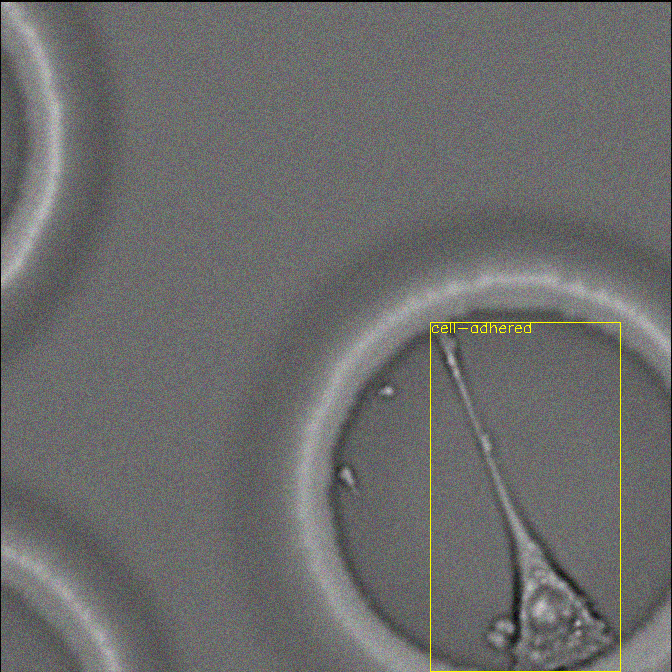

In [17]:
display(show_sample(123455, train_dataset))

### Model selection
### From a pretrained model on COCO (scratch) or an already trained model on our dataset
To continue training a model already trained on our dataset, update the checkpoint. 

In [18]:
pre_trained_model_checkpoint: str = os.path.join(MODEL_PATH, CUSTOM_RT_DETR_WITH_DINOV2_BACKBONE_INITIAL_CHECKPOINT)
# pre_trained_model_checkpoint: str = os.path.join(MODEL_PATH, "checkpoint-53574")
model = RTDetrV2ForObjectDetectionWithCustomBackbone.from_pretrained(pretrained_model_name_or_path=pre_trained_model_checkpoint)

# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print('Device available:' , device)

# move model to the right device
model.train()
model.to(device)

"""
To test the model on some inputs, 
train_iter = iter(train_data_loader)
train_batch = next(train_iter)
train_batch['pixel_values'] = train_batch['pixel_values'].to(device)
train_batch['labels'] = [{k: v.to(device) for k, v in sample.items()} for sample in train_batch['labels']]
with torch.no_grad():
    out = model(**train_batch)
"""

[INFO]: The passed config.backbone_config is a custom one of type Dinov2BackBoneWithFPNConfig. The model and the backbone are instantiated separately as the backbone is not supported by the original model.
[INFO]: The RT-DETRv2 model is instantiated with the backbone_config taken from checkpoints/rt_detr_checkpoints_3/custom_rt_detr_with_dinov2_backbone. This backbone will be replaced with the custom one once the RT-DETR model is instantiated.
[INFO]: DINOv2 parameters loaded from pretrained path: facebook/dinov2-base
Device available: cuda


"\nTo test the model on some inputs, \ntrain_iter = iter(train_data_loader)\ntrain_batch = next(train_iter)\ntrain_batch['pixel_values'] = train_batch['pixel_values'].to(device)\ntrain_batch['labels'] = [{k: v.to(device) for k, v in sample.items()} for sample in train_batch['labels']]\nwith torch.no_grad():\n    out = model(**train_batch)\n"

### Evalutation function
A function to compute COCO mAP and mAR.

In [19]:
from pycocotools.cocoeval import COCOeval

def to_cpu_device(tensor):
    """
    A function to move a CUDA torch input to CPU memory.
    Args:
        tensor (torch tensor).
    Returns:
        Moved to CPU.
    """
    return tensor.detach().cpu() if tensor.requires_grad else tensor.cpu()

def convert_to_xywh(boxes):
    xmin, ymin, xmax, ymax = boxes.unbind(1)
    return torch.stack((xmin, ymin, xmax - xmin, ymax - ymin), dim=1)


def convert_preds_to_coco(predictions):
    coco_results = []
    for original_id, prediction in predictions.items():
        if len(prediction) == 0:
            continue
        
        boxes = prediction["boxes"]
        boxes = convert_to_xywh(boxes).tolist()
        
        scores = prediction["scores"].tolist()
        labels = prediction["labels"].tolist()
         
        coco_results.extend(
            [
                {
                    "image_id": original_id,
                    "category_id": labels[k],
                    "bbox": boxes[k],
                    "score": scores[k],
                }
                for k in range(len(scores))
            ]
        )
    return coco_results

from dataclasses import dataclass

@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, data_loader, image_processor, threshold=0.4, max_dets=100):
        self.image_processor = image_processor
        self.threshold = threshold
        self.test_dataset_coco = data_loader.dataset.dataset_coco
        self.all_predictions = []
        self.all_image_ids = []
        self.max_dets = max_dets

    def collect_image_sizes(self, batch):
        """Collect image sizes across a batch of the dataset as a list of batch_size size (list of 2 elements, height and width)."""
        # we should use size and not 'org_size' this is because we directly use ground truth from the COCO test dataset, which already
        # have the images resized to size
        batch_image_sizes = [to_cpu_device(x["size"]).numpy().tolist() for x in batch]
        return batch_image_sizes

    def collect_predictions(self, batch_predictions, batch_image_sizes):
        post_processed_predictions = []
        batch_logits, batch_boxes = batch_predictions[1], batch_predictions[2]
        output = ModelOutput(logits=batch_logits, pred_boxes=batch_boxes)
        # post_processed_output is a list of batch_size dictionaty elements, each dictionary containing the detections
        # for the images in the batch with keys as 'boxes', 'labels' and 'scores', and values as
        # - 'boxes': a (num_detection, 4) torch.float32 tensor of bounding boxes in (xtl, ytl, xbr, ybr) format
        # - 'labels': a (num_detection, 1) torch.int64 tensor of class IDs
        # - 'scores': a (num_detection, 1) torch.float32 tensor of detection confidences
        post_processed_output = self.image_processor.post_process_object_detection(
            output, threshold=self.threshold, target_sizes=batch_image_sizes
        )        
        # move the detections to CPU
        post_processed_output = [{k: to_cpu_device(v) for k, v in outputs.items()} for outputs in post_processed_output]
        post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions
    
    # metrics should be a dictionary with the following keys: 
    # 'map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large', 
    # 'map_cell', 'mar_100_cell', 'map_bead', 'mar_100_bead', 'map_soma', 'mar_100_soma'
    @torch.no_grad()
    def __call__(self, evaluation_results, compute_result):

        metrics = {
                'map': -1.0, 'map_50': -1.0, 'map_75': -1.0, 
                'map_small': -1.0, 'map_medium': -1.0, 'map_large': -1.0, 
                'mar_1': -1.0, 'mar_10': -1.0, 'mar_' + str(self.max_dets): -1.0, 
                'mar_small': -1.0, 'mar_medium': -1.0, 'mar_large': -1.0
            }

        batch_predictions, batch_targets = evaluation_results.predictions, evaluation_results.label_ids 
        
        batch_image_sizes = self.collect_image_sizes(batch_targets)
        post_processed_batch_predictions = self.collect_predictions(batch_predictions, batch_image_sizes)
        results = {int(target["image_id"].item()): output for target, output in zip(batch_targets, post_processed_batch_predictions)}    
        results = convert_preds_to_coco(results)
        self.all_predictions.extend(results)
        self.all_image_ids += [int(target["image_id"].item()) for target in batch_targets]
        
        if compute_result and len(self.all_predictions) > 0:
            n_threads = torch.get_num_threads()
            # FIXME remove this and make paste_masks_in_image run on the GPU
            torch.set_num_threads(1)
            cpu_device = torch.device("cpu")
    
            coco_gt = self.test_dataset_coco.coco  
            coco_dt = coco_gt.loadRes(self.all_predictions)  # init predictions api
    
            evaluator_time = time.time()
    
            # bounding box evaluation
            coco_evaluator_bbox = COCOeval(coco_gt, coco_dt, "bbox")
            coco_evaluator_bbox.params.maxDets = [1, 10, self.max_dets]
            coco_evaluator_bbox.params.imgIds = self.all_image_ids
            coco_evaluator_bbox.evaluate()
            coco_evaluator_bbox.accumulate()
            coco_evaluator_bbox.summarize()
            evaluator_time = time.time() - evaluator_time
    
            print("evaluator_time:", evaluator_time)

            torch.set_num_threads(n_threads)
            for i, key in enumerate(metrics.keys()):
                metrics[key] = coco_evaluator_bbox.stats[i]
            
            metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

            # clear up the history
            self.all_predictions = []
            self.all_image_ids = []

        if compute_result:
            # clear up the history
            self.all_predictions = []
            self.all_image_ids = []
            
                    
        return metrics
# we should use a very small threshold here to allow MAPEvaluator to use all the predictions with their scores
eval_compute_metrics_fn = MAPEvaluator(data_loader=test_data_loader, image_processor=hg_preprocessor, threshold=0.05, max_dets=100)

### Run Training using Hugging face training script

In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=MODEL_PATH,
    num_train_epochs=NUM_EPOCHS,
    max_grad_norm=0.1,
    learning_rate=LEARNING_RATE,
    warmup_steps=300,
    lr_scheduler_type = "reduce_lr_on_plateau",
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=1,
    torch_empty_cache_steps=int(len(train_dataset) / (5 * TRAIN_BATCH_SIZE)), 
    batch_eval_metrics=True,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=hg_preprocessor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large
1,5.685000,6.437700,0.425400,0.613400,0.495600,0.169000,0.453000,0.421100,0.236100,0.562700,0.695600,0.528200,0.778100,0.751300


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Loading and preparing results...
DONE (t=22.50s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=219.99s).
Accumulating evaluation results...
DONE (t=78.66s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.425
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.613
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.496
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.169
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.453
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.421
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.236
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.563
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.696
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDet

In [ ]:
# Epoch	Training Loss	Validation Loss	Map	Map 50	Map 75	Map Small	Map Medium	Map Large	Mar 1	Mar 10	Mar 100	Mar Small	Mar Medium	Mar Large
# 1	8.449600	9.477483	0.453100	0.705400	0.533500	0.283200	0.465200	0.212800	0.157800	0.492900	0.565200	0.344000	0.602500	0.315500
# 2	8.223800	8.733813	0.507400	0.760000	0.607400	0.280900	0.502300	0.302800	0.177600	0.528700	0.603200	0.350800	0.608500	0.439900
# 3	8.031400	11.996222	0.396600	0.567000	0.475000	0.275600	0.403500	0.157200	0.101200	0.375000	0.448000	0.308800	0.463400	0.178200
# 4	7.950800	7.612844	0.504700	0.726500	0.611500	0.294000	0.520800	0.313600	0.158200	0.498000	0.568800	0.339400	0.591400	0.378500
# 5	7.697000	11.295392	0.341100	0.472200	0.414900	0.292200	0.351300	0.094000	0.082000	0.321900	0.400900	0.336800	0.410300	0.103900
# 6	7.596000	10.256644	0.424500	0.596800	0.505400	0.282700	0.425000	0.217800	0.115500	0.406500	0.480600	0.330500	0.480500	0.243900
# 7	7.374200	9.024280	0.534400	0.745000	0.632700	0.315200	0.520700	0.328600	0.167600	0.534500	0.612600	0.361800	0.611800	0.406600
# 8	7.285000	10.126621	0.481100	0.684100	0.571400	0.292400	0.471100	0.278200	0.144400	0.470500	0.542500	0.345000	0.532300	0.315900
# 9	7.090000	10.538335	0.491200	0.689400	0.585500	0.281600	0.485300	0.337100	0.151500	0.481900	0.552100	0.318300	0.555200	0.383000


# load the model, the latest saved checkpoint will be loaded

pre_trained_model_checkpoint: str = os.path.join(MODEL_PATH, "checkpoint-428592")
model = RTDetrV2ForObjectDetectionWithCustomBackbone.from_pretrained(pretrained_model_name_or_path=pre_trained_model_checkpoint)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


DETECTION_REMAP = None
# DETECTION_REMAP = {"cell-adhered": "cell", "soma": "cell"}


RESIZE: Final[Dict[Tuple[int, int, str], Tuple[int, int]]] = {
    (2000, 1600, "10x"): (1000, 800),
    (4512, 4512, "10x"): (4512, 4512),
    (4512, 4512, "4x"): (4512, 4512),
}
# A dictionary with keys as the input (original) image size (width, height, magnification)
# tuple and values as the list of coordinates (xtl, ytl, xbr, ybr) of sub-images/crops
# to run YOLOv5 on each
# note that the crop coordinates are with respect to resized image dimensions specified above
CROP_CORNERS: Final[Dict[Tuple[int, int, str], List[List[int]]]] = {
    (2000, 1600, "10x"): [
        [0, 0, 640, 640],
        [0, 160, 640, 800],
        [360, 0, 1000, 640],
        [360, 160, 1000, 800],
    ],
    (4512, 4512, "10x"): [
        [0, 0, 672, 672],
        [0, 256, 672, 928],
        [0, 512, 672, 1184],
        [0, 768, 672, 1440],
        [0, 1024, 672, 1696],
        [0, 1280, 672, 1952],
        [0, 1536, 672, 2208],
        [0, 1792, 672, 2464],
        [0, 2048, 672, 2720],
        [0, 2304, 672, 2976],
        [0, 2560, 672, 3232],
        [0, 2816, 672, 3488],
        [0, 3072, 672, 3744],
        [0, 3328, 672, 4000],
        [0, 3584, 672, 4256],
        [0, 3840, 672, 4512],
        [256, 0, 928, 672],
        [256, 256, 928, 928],
        [256, 512, 928, 1184],
        [256, 768, 928, 1440],
        [256, 1024, 928, 1696],
        [256, 1280, 928, 1952],
        [256, 1536, 928, 2208],
        [256, 1792, 928, 2464],
        [256, 2048, 928, 2720],
        [256, 2304, 928, 2976],
        [256, 2560, 928, 3232],
        [256, 2816, 928, 3488],
        [256, 3072, 928, 3744],
        [256, 3328, 928, 4000],
        [256, 3584, 928, 4256],
        [256, 3840, 928, 4512],
        [512, 0, 1184, 672],
        [512, 256, 1184, 928],
        [512, 512, 1184, 1184],
        [512, 768, 1184, 1440],
        [512, 1024, 1184, 1696],
        [512, 1280, 1184, 1952],
        [512, 1536, 1184, 2208],
        [512, 1792, 1184, 2464],
        [512, 2048, 1184, 2720],
        [512, 2304, 1184, 2976],
        [512, 2560, 1184, 3232],
        [512, 2816, 1184, 3488],
        [512, 3072, 1184, 3744],
        [512, 3328, 1184, 4000],
        [512, 3584, 1184, 4256],
        [512, 3840, 1184, 4512],
        [768, 0, 1440, 672],
        [768, 256, 1440, 928],
        [768, 512, 1440, 1184],
        [768, 768, 1440, 1440],
        [768, 1024, 1440, 1696],
        [768, 1280, 1440, 1952],
        [768, 1536, 1440, 2208],
        [768, 1792, 1440, 2464],
        [768, 2048, 1440, 2720],
        [768, 2304, 1440, 2976],
        [768, 2560, 1440, 3232],
        [768, 2816, 1440, 3488],
        [768, 3072, 1440, 3744],
        [768, 3328, 1440, 4000],
        [768, 3584, 1440, 4256],
        [768, 3840, 1440, 4512],
        [1024, 0, 1696, 672],
        [1024, 256, 1696, 928],
        [1024, 512, 1696, 1184],
        [1024, 768, 1696, 1440],
        [1024, 1024, 1696, 1696],
        [1024, 1280, 1696, 1952],
        [1024, 1536, 1696, 2208],
        [1024, 1792, 1696, 2464],
        [1024, 2048, 1696, 2720],
        [1024, 2304, 1696, 2976],
        [1024, 2560, 1696, 3232],
        [1024, 2816, 1696, 3488],
        [1024, 3072, 1696, 3744],
        [1024, 3328, 1696, 4000],
        [1024, 3584, 1696, 4256],
        [1024, 3840, 1696, 4512],
        [1280, 0, 1952, 672],
        [1280, 256, 1952, 928],
        [1280, 512, 1952, 1184],
        [1280, 768, 1952, 1440],
        [1280, 1024, 1952, 1696],
        [1280, 1280, 1952, 1952],
        [1280, 1536, 1952, 2208],
        [1280, 1792, 1952, 2464],
        [1280, 2048, 1952, 2720],
        [1280, 2304, 1952, 2976],
        [1280, 2560, 1952, 3232],
        [1280, 2816, 1952, 3488],
        [1280, 3072, 1952, 3744],
        [1280, 3328, 1952, 4000],
        [1280, 3584, 1952, 4256],
        [1280, 3840, 1952, 4512],
        [1536, 0, 2208, 672],
        [1536, 256, 2208, 928],
        [1536, 512, 2208, 1184],
        [1536, 768, 2208, 1440],
        [1536, 1024, 2208, 1696],
        [1536, 1280, 2208, 1952],
        [1536, 1536, 2208, 2208],
        [1536, 1792, 2208, 2464],
        [1536, 2048, 2208, 2720],
        [1536, 2304, 2208, 2976],
        [1536, 2560, 2208, 3232],
        [1536, 2816, 2208, 3488],
        [1536, 3072, 2208, 3744],
        [1536, 3328, 2208, 4000],
        [1536, 3584, 2208, 4256],
        [1536, 3840, 2208, 4512],
        [1792, 0, 2464, 672],
        [1792, 256, 2464, 928],
        [1792, 512, 2464, 1184],
        [1792, 768, 2464, 1440],
        [1792, 1024, 2464, 1696],
        [1792, 1280, 2464, 1952],
        [1792, 1536, 2464, 2208],
        [1792, 1792, 2464, 2464],
        [1792, 2048, 2464, 2720],
        [1792, 2304, 2464, 2976],
        [1792, 2560, 2464, 3232],
        [1792, 2816, 2464, 3488],
        [1792, 3072, 2464, 3744],
        [1792, 3328, 2464, 4000],
        [1792, 3584, 2464, 4256],
        [1792, 3840, 2464, 4512],
        [2048, 0, 2720, 672],
        [2048, 256, 2720, 928],
        [2048, 512, 2720, 1184],
        [2048, 768, 2720, 1440],
        [2048, 1024, 2720, 1696],
        [2048, 1280, 2720, 1952],
        [2048, 1536, 2720, 2208],
        [2048, 1792, 2720, 2464],
        [2048, 2048, 2720, 2720],
        [2048, 2304, 2720, 2976],
        [2048, 2560, 2720, 3232],
        [2048, 2816, 2720, 3488],
        [2048, 3072, 2720, 3744],
        [2048, 3328, 2720, 4000],
        [2048, 3584, 2720, 4256],
        [2048, 3840, 2720, 4512],
        [2304, 0, 2976, 672],
        [2304, 256, 2976, 928],
        [2304, 512, 2976, 1184],
        [2304, 768, 2976, 1440],
        [2304, 1024, 2976, 1696],
        [2304, 1280, 2976, 1952],
        [2304, 1536, 2976, 2208],
        [2304, 1792, 2976, 2464],
        [2304, 2048, 2976, 2720],
        [2304, 2304, 2976, 2976],
        [2304, 2560, 2976, 3232],
        [2304, 2816, 2976, 3488],
        [2304, 3072, 2976, 3744],
        [2304, 3328, 2976, 4000],
        [2304, 3584, 2976, 4256],
        [2304, 3840, 2976, 4512],
        [2560, 0, 3232, 672],
        [2560, 256, 3232, 928],
        [2560, 512, 3232, 1184],
        [2560, 768, 3232, 1440],
        [2560, 1024, 3232, 1696],
        [2560, 1280, 3232, 1952],
        [2560, 1536, 3232, 2208],
        [2560, 1792, 3232, 2464],
        [2560, 2048, 3232, 2720],
        [2560, 2304, 3232, 2976],
        [2560, 2560, 3232, 3232],
        [2560, 2816, 3232, 3488],
        [2560, 3072, 3232, 3744],
        [2560, 3328, 3232, 4000],
        [2560, 3584, 3232, 4256],
        [2560, 3840, 3232, 4512],
        [2816, 0, 3488, 672],
        [2816, 256, 3488, 928],
        [2816, 512, 3488, 1184],
        [2816, 768, 3488, 1440],
        [2816, 1024, 3488, 1696],
        [2816, 1280, 3488, 1952],
        [2816, 1536, 3488, 2208],
        [2816, 1792, 3488, 2464],
        [2816, 2048, 3488, 2720],
        [2816, 2304, 3488, 2976],
        [2816, 2560, 3488, 3232],
        [2816, 2816, 3488, 3488],
        [2816, 3072, 3488, 3744],
        [2816, 3328, 3488, 4000],
        [2816, 3584, 3488, 4256],
        [2816, 3840, 3488, 4512],
        [3072, 0, 3744, 672],
        [3072, 256, 3744, 928],
        [3072, 512, 3744, 1184],
        [3072, 768, 3744, 1440],
        [3072, 1024, 3744, 1696],
        [3072, 1280, 3744, 1952],
        [3072, 1536, 3744, 2208],
        [3072, 1792, 3744, 2464],
        [3072, 2048, 3744, 2720],
        [3072, 2304, 3744, 2976],
        [3072, 2560, 3744, 3232],
        [3072, 2816, 3744, 3488],
        [3072, 3072, 3744, 3744],
        [3072, 3328, 3744, 4000],
        [3072, 3584, 3744, 4256],
        [3072, 3840, 3744, 4512],
        [3328, 0, 4000, 672],
        [3328, 256, 4000, 928],
        [3328, 512, 4000, 1184],
        [3328, 768, 4000, 1440],
        [3328, 1024, 4000, 1696],
        [3328, 1280, 4000, 1952],
        [3328, 1536, 4000, 2208],
        [3328, 1792, 4000, 2464],
        [3328, 2048, 4000, 2720],
        [3328, 2304, 4000, 2976],
        [3328, 2560, 4000, 3232],
        [3328, 2816, 4000, 3488],
        [3328, 3072, 4000, 3744],
        [3328, 3328, 4000, 4000],
        [3328, 3584, 4000, 4256],
        [3328, 3840, 4000, 4512],
        [3584, 0, 4256, 672],
        [3584, 256, 4256, 928],
        [3584, 512, 4256, 1184],
        [3584, 768, 4256, 1440],
        [3584, 1024, 4256, 1696],
        [3584, 1280, 4256, 1952],
        [3584, 1536, 4256, 2208],
        [3584, 1792, 4256, 2464],
        [3584, 2048, 4256, 2720],
        [3584, 2304, 4256, 2976],
        [3584, 2560, 4256, 3232],
        [3584, 2816, 4256, 3488],
        [3584, 3072, 4256, 3744],
        [3584, 3328, 4256, 4000],
        [3584, 3584, 4256, 4256],
        [3584, 3840, 4256, 4512],
        [3840, 0, 4512, 672],
        [3840, 256, 4512, 928],
        [3840, 512, 4512, 1184],
        [3840, 768, 4512, 1440],
        [3840, 1024, 4512, 1696],
        [3840, 1280, 4512, 1952],
        [3840, 1536, 4512, 2208],
        [3840, 1792, 4512, 2464],
        [3840, 2048, 4512, 2720],
        [3840, 2304, 4512, 2976],
        [3840, 2560, 4512, 3232],
        [3840, 2816, 4512, 3488],
        [3840, 3072, 4512, 3744],
        [3840, 3328, 4512, 4000],
        [3840, 3584, 4512, 4256],
        [3840, 3840, 4512, 4512]
    ],
}

CROP_CORNERS[(4512, 4512, "4x")] = CROP_CORNERS[(4512, 4512, "10x")]
model_param_dict = {}
model_param_dict['model_state_dict'] = model.state_dict()
model_param_dict['label_map'] = LABEL_MAP
model_param_dict['resize_dict'] = RESIZE
model_param_dict['crop_corners_dict'] = CROP_CORNERS
if DETECTION_REMAP is not None:
    model_param_dict['detected_class_names_remap'] = DETECTION_REMAP

torch.save(model_param_dict, os.path.join(MODEL_PATH, 'final.pt'))

In [ ]:
from pprint import pprint

metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix="eval")
pprint(metrics)

### Run Inference
To run inference on a previously trained model, run the cells above up to "Cell size analysis".

In [ ]:
from transformers import RTDetrImageProcessor

def to_numpy(tensor):
    """
    A function to convert a torch input to numpy array.
    Args:
        tensor (torch tensor).
    Returns:
        Converted to numpy array.
    """
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

def show_predictions(image_pil, predictions, color_depth=12):
    # convert to a numpy array
    image = np.array(image_pil)
    # scale
    image = (255 * image.astype(float) / (2**color_depth - 1)).astype(np.uint8)
    # convert to 3-channels
    image = np.repeat(np.expand_dims(image, axis=2), 3, axis=2)

    boxes = predictions['boxes']
    labels = predictions['labels']

    for i in range(len(boxes)):
        # the bounding box
        (xtl, ytl, xbr, ybr) = boxes[i].astype(int)
        # use green color for masks
        color = COLORS[(labels[i] + 1) % len(COLORS)]
        
        if labels[i] in LABEL_MAP:
            text = LABEL_MAP[labels[i]]
        else:
            print('Incorrect ID was found %s' %labels[i])
            text = 'Unknown'
        
        # add label
        cv2.putText(image, text, (xtl, ytl + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        cv2.rectangle(image, (xtl, ytl), (xbr, ybr), color, 1)
        
    # convert to PIL image to display
    return Image.fromarray(image)

# we return the results in the same format as Mask R-CNN and YOLO to be able to reuse the codes written for that model
def predict_batch(model, input_images_list, device, detection_threshold=0.4):
    
    model.eval()
    model.to(device)

    # convert to 3-channel images if needed, and store the original image dimensions for 
    # post processing
    images_list: List[np.array] = []
    org_img_dims: List[Tuple[int, int]] = []
    
    for img in input_images_list:
        img_shape: tuple = img.shape
        if len(img_shape) < 3:
            images_list.append(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
        else:
            images_list.append(img)
        org_img_dims.append(img_shape[:2])
    
    hg_preprocessor = RTDetrImageProcessor(
        do_convert_annotations=True,
        do_resize=True,
        size={"width": MODEL_INPUT_SIZE, "height": MODEL_INPUT_SIZE},
        reduce_labels=False,
        do_rescale=True, 
        do_normalize=True
    )
       
    processed_imgs_dict = hg_preprocessor(images_list, return_tensors="pt")
    with torch.no_grad():
        outputs = model(pixel_values=processed_imgs_dict["pixel_values"].to(device))
        
        processed_outputs = hg_preprocessor.post_process_object_detection(
            outputs, threshold=detection_threshold, target_sizes=org_img_dims
        )

    # processed_outputs is a list of len(input_images_list) dictionary elements, each dictionary containing the detections
    # for the input image in the input list with keys as 'boxes', 'labels' and 'scores', and values as
    # - 'boxes': a (num_detection, 4) torch.float32 tensor of bounding boxes in (xtl, ytl, xbr, ybr) format
    # - 'labels': a (num_detection, 1) torch.int64 tensor of class IDs
    # - 'scores': a (num_detection, 1) torch.float32 tensor of detection confidences
        
    if len(processed_outputs) == 0:
        # this should not happen and is not expected, return as if the model has not detected anything (for the whole list of images)
        return [
            {'boxes': [],
             'labels': [],
             'scores': [],
            }
        ] * len(images_list)

    # move to CPU and convert to numpy arrays before returning
    return [{k: to_numpy(v) for k, v in result.items()} for result in processed_outputs]

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
from collections import OrderedDict

saved_model_param: Union[OrderedDict, list] = torch.load(os.path.join(MODEL_PATH, 'final.pt'), map_location=device)
if (isinstance(saved_model_param, dict) and "model_state_dict" in saved_model_param):
    # the weights file contains the model state dictionary (the weights) and the label map (both are
    # mandatory) and potentially other model related configs
    # in case a dictionary is provided, the keys and values are as following:
    # - 'model_state_dict': model state dictionary (mandatory)
    # - 'label_map': label map (mandatory)
    # - 'resize_dict': resize dictionary (optional, for resizing and cropping images during inference)
    # - 'crop_corners_dict': crop corners dictionary (optional, for cropping images during inference)
    # ... other optional fields to be added in future
    model_state_dict = saved_model_param["model_state_dict"]
    if "label_map" in saved_model_param:
        loaded_label_map = saved_model_param["label_map"]
    else:
        print(
            f"The weights file should contain the label map but it missing. "
            f"This should never happen..."
        )
        loaded_label_map = None
        
    if ("resize_dict" in saved_model_param and "crop_corners_dict" in saved_model_param):
        # resize and crop corners are also provided in the weights file
        print(
            f"The resize and crop_corners dictionary are also provided in the weights file."
        )
        
    if "detected_class_names_remap" in saved_model_param:
        print(
            f"The class names detected by the model will be re-mapped following this mapping: "
            f" {saved_model_param['detected_class_names_remap']}."
        )

else:
    # the file only contains the model state dictionary
    model_state_dict = saved_model_param
    loaded_label_map = None

model_config = RTDetrV2ConfigWithCustomBackBone.from_pretrained(
    os.path.join(MODEL_PATH, CUSTOM_RT_DETR_WITH_DINOV2_BACKBONE_INITIAL_CHECKPOINT)
)
# build the model (with random weights), we do this to make sure the config is correct
model = RTDetrV2ForObjectDetectionWithCustomBackbone(model_config)
model.load_state_dict(model_state_dict)
model.to(device)
model.eval()

In [ ]:
# idx = 145123
idx = 14356
# img_path = os.path.join(test_dataset.images_path, test_dataset.imgs[idx])
img_id = test_dataset.dataset_coco.coco.getImgIds()[idx]
img_path = os.path.join(test_dataset.dataset_coco.root, test_dataset.dataset_coco.coco.imgs[img_id]['file_name'])
img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

In [ ]:
out = predict_batch(model, [img], device, 0.45)[0]

In [ ]:
display(show_predictions(img, out, 8))

In [ ]:
display(show_sample(idx, test_dataset))

### Measuring the run-time

In [ ]:
import time
start = time.time()
for i in range(10):
    out = predict_batch(model, [img], device)[0]
print('Running RT-DETR took {} ms'.format((time.time() - start) * 100))